<a href="https://colab.research.google.com/github/ktripa/DL_Hydrology/blob/main/SPI_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Author: Kumar Puran Tripathy (PhD, CEWS lab)
# Class: Hydroclimatic Extremes
# Instructor: Ashok Kumar Mishra
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                       ARIMA TIME SERIES ANALYSIS                            ║
# ║     Date-based Split (Train: 1901–1989 | Test: 1990–2018)                    ║
# ║         Original Series | ACF/PACF | (Next: Differencing & ARIMA)            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─── 0. INSTALL & IMPORT ──────────────────────────────────────────────────────
# !pip install statsmodels openpyxl


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools    import adfuller, acf, pacf
from statsmodels.tsa.arima.model  import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy                        import stats

# ─── GLOBAL STYLE ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f172a', 'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#475569', 'axes.labelcolor':  '#e2e8f0',
    'xtick.color':      '#94a3b8', 'ytick.color':      '#94a3b8',
    'text.color':       '#e2e8f0', 'grid.color':       '#334155',
    'grid.linestyle':   '--',      'grid.alpha':        0.5,
    'font.family':      'monospace','axes.titlesize':   11,
    'axes.labelsize':   10,        'legend.facecolor': '#1e293b',
    'legend.edgecolor': '#475569',
})
AMBER  = '#f59e0b'; GREEN  = '#34d399'; BLUE  = '#60a5fa'
ROSE   = '#f87171'; PURPLE = '#a78bfa'; SLATE = '#94a3b8'
LEAD_COLORS = ['#f87171','#fb923c','#fbbf24','#34d399','#38bdf8','#c084fc']
LEAD_LABELS = ['Lead-1','Lead-2','Lead-3','Lead-4','Lead-5','Lead-6']

# ─── HELPER: custom ACF/PACF plot ─────────────────────────────────────────────
def styled_acf_pacf(series, title, filename, nlags=40, color=BLUE):
    series = series.dropna()
    acf_vals,  acf_ci  = acf (series, nlags=nlags, alpha=0.05)
    pacf_vals, pacf_ci = pacf(series, nlags=nlags, alpha=0.05, method='ywm')
    lags = np.arange(nlags + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=12, color=AMBER, fontweight='bold')

    for ax, vals, ci, lbl in [
        (axes[0], acf_vals, acf_ci, 'ACF'),
        (axes[1], pacf_vals, pacf_ci, 'PACF')
    ]:
        cil = ci[:, 0] - vals
        ciu = ci[:, 1] - vals
        ax.fill_between(lags, cil, ciu, alpha=0.15, color=AMBER, label='95% CI')
        ax.axhline(0, color='#475569', lw=1)
        for lag in lags[1:]:
            c = ROSE if (vals[lag] < cil[lag] or vals[lag] > ciu[lag]) else SLATE
            ax.vlines(lag, 0, vals[lag], colors=c, lw=2)
            ax.plot(lag, vals[lag], 'o', color=c, ms=5, zorder=3)
        ax.vlines(0, 0, vals[0], colors=SLATE, lw=2)
        ax.plot(0, vals[0], 'o', color=SLATE, ms=5)
        ax.set_xlabel('Lag'); ax.set_ylabel(lbl)
        ax.set_title(f'{lbl}', color=color, fontweight='bold')
        ax.set_xlim(-0.5, nlags + 0.5)
        ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='#0f172a')
    plt.show(); print(f"  ✓ Saved: {filename}")




In [18]:
from google.colab import files
uploaded = files.upload()

Saving Climate division 1.xlsx to Climate division 1 (1).xlsx


## Section 1 — Load Data & Train/Test Split

**SPI-3** (3-month Standardised Precipitation Index) is already a
stationary-by-construction index — it is standardised to mean=0, std=1 by
design. This means **d = 0** (no differencing needed), and we look directly
at ACF/PACF to identify p and q.

- **Training: 1980–2009** (30 years × 12 months = 360 observations)
- **Test: 2010–2018** (9 years × 12 months = 108 observations)


  Training : 1980-01-01 → 2009-12-01  (360 months)
  Test     : 2010-01-01  → 2018-11-01  (107 months)
  Train stats: mean=0.112  std=0.960  min=-2.510  max=2.540


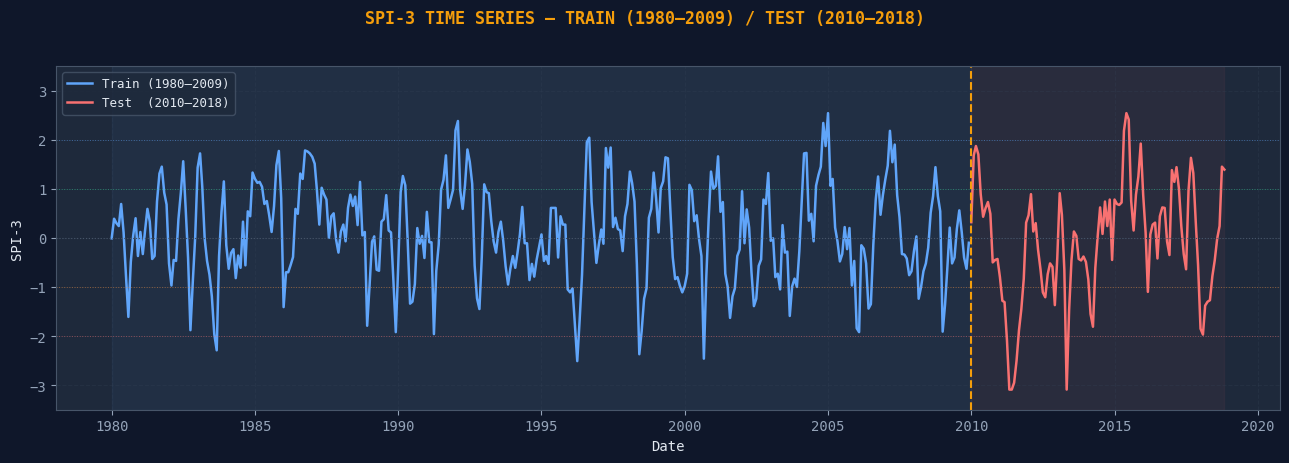

  ✓ Saved: 01_spi3_train_test_split.png


In [19]:


df_raw = pd.read_excel('Climate division 1.xlsx', header=0)
if any(str(c).startswith("Unnamed") for c in df_raw.columns):
    df_raw.columns = df_raw.iloc[0]
    df_raw = df_raw.drop(0).reset_index(drop=True)

df = df_raw.copy()
df['YearMonth'] = df['YearMonth'].astype(str).str.strip()
df['Year']  = df['YearMonth'].str[:4].astype(int)
df['Month'] = df['YearMonth'].str[4:].astype(int)
df['Date']  = pd.to_datetime(dict(year=df['Year'], month=df['Month'], day=1))
df = df.sort_values('Date').set_index('Date')
df = df.replace([-99.99, -9999, -999.9, -99.9], np.nan)

y = df['SP03'].astype(float)
train = y.loc['1980-01-01':'2009-12-01'].dropna()
test  = y.loc['2010-01-01':].dropna()
n_train = len(train); n_test = len(test)

print(f"\n  Training : {train.index.min().date()} → {train.index.max().date()}  ({n_train} months)")
print(f"  Test     : {test.index.min().date()}  → {test.index.max().date()}  ({n_test} months)")
print(f"  Train stats: mean={train.mean():.3f}  std={train.std():.3f}  "
      f"min={train.min():.3f}  max={train.max():.3f}")

fig, ax = plt.subplots(figsize=(13, 4.5))
fig.suptitle('SPI-3 TIME SERIES — TRAIN (1980–2009) / TEST (2010–2018)',
             fontsize=12, color=AMBER, fontweight='bold', y=1.02)
ax.plot(train.index, train.values, color=BLUE, lw=1.8, label='Train (1980–2009)')
ax.plot(test.index,  test.values,  color=ROSE, lw=1.8, label='Test  (2010–2018)')
split_date = pd.to_datetime('2010-01-01')
ax.axvline(split_date, color=AMBER, lw=1.5, ls='--')
ax.axhline(0, color='#475569', lw=0.8, ls=':')
ax.fill_betweenx([-3.5, 3.5], train.index.min(), split_date, alpha=0.05, color=BLUE)
ax.fill_betweenx([-3.5, 3.5], split_date, test.index.max(),  alpha=0.05, color=ROSE)
# SPI threshold lines
for val, lbl, c in [(-2,'Extreme Dry',ROSE),(-1,'Moderate Dry','#fb923c'),
                     (1,'Moderate Wet',GREEN),(2,'Extreme Wet',BLUE)]:
    ax.axhline(val, color=c, lw=0.7, ls=':', alpha=0.5)
ax.set_ylabel('SPI-3'); ax.set_xlabel('Date')
ax.legend(fontsize=9, loc='upper left'); ax.grid(True, alpha=0.3)
ax.set_ylim(-3.5, 3.5)
plt.tight_layout()
plt.savefig('01_spi3_train_test_split.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show(); print("  ✓ Saved: 01_spi3_train_test_split.png")

## Section 2 — ACF & PACF of Training Series + ADF Test

Since SPI-3 is already stationary by construction (standardised), we
expect the **ADF test to confirm stationarity** (p < 0.05) and set **d = 0**.

### Reading ACF/PACF for ARMA identification
| Pattern | Suggested model |
|---------|----------------|
| PACF cuts off at lag p, ACF tails off | AR(p) |
| ACF cuts off at lag q, PACF tails off | MA(q) |
| Both tail off gradually | ARMA(p,q) |
| Spike at lag 12, 24... | Seasonal component (consider SARIMA) |


  SECTION 2: ACF & PACF + ADF TEST (Training Set, d=0)


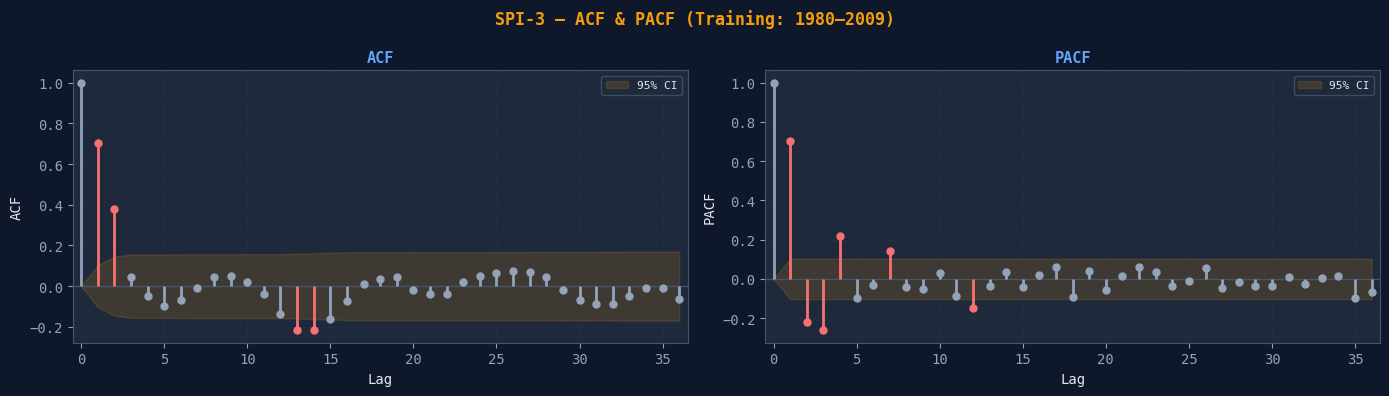

  ✓ Saved: 02_spi3_acf_pacf_train.png

  ADF Test — Training Series:
    Statistic : -6.2783
    p-value   : 0.0000  ✓ STATIONARY → d=0 confirmed
    Critical  : 1%=-3.449  5%=-2.870


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — ACF / PACF + ADF TEST (TRAINING DATA)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 2: ACF & PACF + ADF TEST (Training Set, d=0)")
print("=" * 70)

styled_acf_pacf(train, 'SPI-3 — ACF & PACF (Training: 1980–2009)',
                '02_spi3_acf_pacf_train.png', nlags=36, color=BLUE)

adf = adfuller(train, autolag='AIC')
print(f"\n  ADF Test — Training Series:")
print(f"    Statistic : {adf[0]:.4f}")
print(f"    p-value   : {adf[1]:.4f}  "
      f"{'✓ STATIONARY → d=0 confirmed' if adf[1]<=0.05 else '✗ NON-STATIONARY → need differencing'}")
print(f"    Critical  : 1%={adf[4]['1%']:.3f}  5%={adf[4]['5%']:.3f}")


#
> **📊 Interpretation:** SPI is stationary by construction so ADF should
> reject the unit root (p << 0.05). In the ACF, look for: (a) decay within
> first few lags → short-memory process; (b) spikes near lags 12, 24 →
> seasonal dependence. In the PACF, a sharp cut-off at lag 1 suggests AR(1)
> as the dominant structure.

## Section 3 — Candidate Model Comparison (AIC / BIC)

We test pure AR, pure MA, and mixed ARMA models, all with d=0 since
SPI-3 is already stationary.

| Model | # params | Notes |
|-------|---------|-------|
| AR(1–4) | 2–5 | Only past values |
| ARMA(1,1), (2,1) | 3–4 | Mixed structure |
| ARMA(1,2), (2,2) | 4–5 | Richer MA part |

**Selection rule:** lowest AIC balances fit vs parsimony.


  SECTION 3: CANDIDATE ARIMA MODELS (d=0) — AIC / BIC

  Model                 AIC        BIC       HQIC     LogLik           σ²
  ──────────────────────────────────────────────────────────────
  ARIMA(1, 0, 0)    753.881    765.539    758.517   -373.941       0.4666
  ARIMA(2, 0, 0)    738.119    753.664    744.300   -365.060       0.4440
  ARIMA(3, 0, 0)    714.596    734.027    722.322   -352.298       0.4134
  ARIMA(4, 0, 0)    699.362    722.678    708.633   -343.681       0.3939
  ARIMA(1, 0, 1)    746.435    761.979    752.615   -369.217       0.4545
  ARIMA(2, 0, 1)    730.830    750.260    738.556   -360.415       0.4327
  ARIMA(1, 0, 2)    685.036    704.466    692.762   -337.518       0.3805
  ARIMA(2, 0, 2)    686.915    710.232    696.186   -337.458       0.3804

  ✓ Best model by AIC: ARIMA(1, 0, 2)


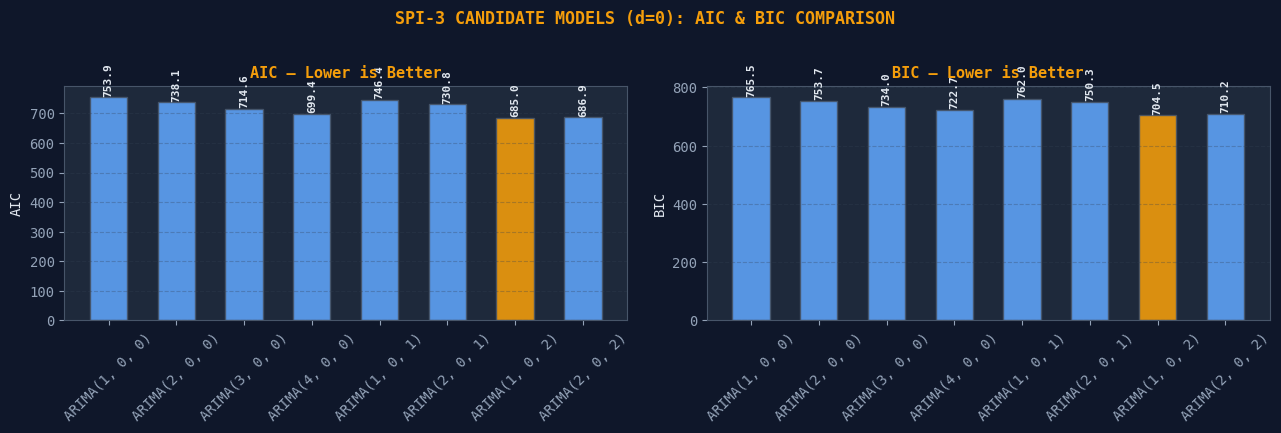

  ✓ Saved: 03_spi3_model_comparison.png


In [21]:

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — CANDIDATE MODELS: AIC / BIC
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 3: CANDIDATE ARIMA MODELS (d=0) — AIC / BIC")
print("=" * 70)

candidate_orders = [
    (1,0,0),(2,0,0),(3,0,0),(4,0,0),
    (1,0,1),(2,0,1),
    (1,0,2),(2,0,2)
]
model_results = {}

print(f"\n  {'Model':<14} {'AIC':>10} {'BIC':>10} {'HQIC':>10} {'LogLik':>10} {'σ²':>12}")
print("  " + "─" * 62)
for order in candidate_orders:
    mod = ARIMA(train, order=order).fit()
    model_results[order] = mod
    sig2 = np.var(mod.resid)
    print(f"  ARIMA{str(order):<9} {mod.aic:>10.3f} {mod.bic:>10.3f} "
          f"{mod.hqic:>10.3f} {mod.llf:>10.3f} {sig2:>12.4f}")

best_order = min(model_results, key=lambda o: model_results[o].aic)
print(f"\n  ✓ Best model by AIC: ARIMA{best_order}")

# Plot AIC/BIC
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
fig.suptitle('SPI-3 CANDIDATE MODELS (d=0): AIC & BIC COMPARISON',
             fontsize=12, color=AMBER, fontweight='bold', y=1.02)
labels   = [f'ARIMA{o}' for o in candidate_orders]
aic_vals = [model_results[o].aic for o in candidate_orders]
bic_vals = [model_results[o].bic for o in candidate_orders]
colors_bar = [AMBER if o == best_order else BLUE for o in candidate_orders]

for ax, vals, metric in [(axes[0], aic_vals, 'AIC'), (axes[1], bic_vals, 'BIC')]:
    bars = ax.bar(labels, vals, color=colors_bar, edgecolor='#475569',
                  width=0.55, alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + 0.05*(max(vals)-min(vals)),
                f'{v:.1f}', ha='center', va='bottom', fontsize=8,
                color='#e2e8f0', fontweight='bold', rotation=90)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} — Lower is Better', color=AMBER, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('03_spi3_model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show(); print("  ✓ Saved: 03_spi3_model_comparison.png")


## Section 4 — ARIMA(1,0,2): Full Equation Derivation

### Backshift form
$$(1 - \phi_1 B)\,Y_t = c + (1 + \theta_1 B + \theta_2 B^2)\,\varepsilon_t$$

### Expand operators ($B^k Y_t = Y_{t-k}$, $B^k \varepsilon_t = \varepsilon_{t-k}$):
$$Y_t = c + \phi_1 Y_{t-1} + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2}$$

### One-step-ahead forecast ($E[\varepsilon_t] = 0$, past errors are **known**):
$$\boxed{\hat{Y}_t = c + \phi_1 Y_{t-1} + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2}}$$

### The residual bank rule
- $\varepsilon_{t-1}$ and $\varepsilon_{t-2}$ **already happened** → they are known numbers
- If $t-1$ or $t-2$ is in the **training period** → use `model.resid`
- If $t-1$ or $t-2$ is in the **test period** → use residuals computed at
  previous test steps: $\varepsilon_t = Y_t - \hat{Y}_t$ (and stored)
- If $t-1$ or $t-2$ is in the **future** (multi-step) → set to 0

---
╚═══════════════════════════════════════════════════════════════════════════╝

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — ARIMA(1,0,2): COEFFICIENTS & EQUATION
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 4: ARIMA(1,0,2) — FIT ONCE ON TRAINING DATA")
print("=" * 70)

# ─── FIT ONCE ON TRAINING DATA — coefficients are FIXED for all forecasts ────
FINAL_ORDER = (1, 0, 2)
final_model = ARIMA(train, order=FINAL_ORDER).fit()
pnames = list(final_model.param_names)
pmap   = dict(zip(pnames, final_model.params))

c_    = pmap.get('const', 0.0)
phi1  = pmap.get('ar.L1',  np.nan)
th1   = pmap.get('ma.L1',  np.nan)
th2   = pmap.get('ma.L2',  np.nan)
sigma2 = np.var(final_model.resid)

print(f"\n  ── Fixed Coefficients (fit on training only) ───────────────────")
print(f"    c  (const) = {c_:+.6f}")
print(f"    φ₁ (ar.L1) = {phi1:+.6f}")
print(f"    θ₁ (ma.L1) = {th1:+.6f}")
print(f"    θ₂ (ma.L2) = {th2:+.6f}")
print(f"    σ²         = {sigma2:.6f}")
mu = c_ / (1 - phi1) if abs(phi1) < 1 else np.nan
if np.isfinite(mu):
    print(f"    μ = c/(1−φ₁) = {mu:+.6f}  (long-run mean)")

print(f"""
  ── FORECASTING EQUATION ─────────────────────────────────────────────

    Ŷₜ = {c_:+.4f} + ({phi1:+.4f})·Yₜ₋₁
             + ({th1:+.4f})·εₜ₋₁
             + ({th2:+.4f})·εₜ₋₂

  εₜ₋₁ and εₜ₋₂ come from the RESIDUAL BANK (see Section 5).
  Yₜ₋₁ is always the ACTUAL observed value (one-step-ahead).
""")

print(final_model.summary())








  SECTION 4: ARIMA(1,0,2) — FIT ONCE ON TRAINING DATA

  ── Fixed Coefficients (fit on training only) ───────────────────
    c  (const) = +0.111255
    φ₁ (ar.L1) = +0.147530
    θ₁ (ma.L1) = +0.744776
    θ₂ (ma.L2) = +0.632790
    σ²         = 0.380484
    μ = c/(1−φ₁) = +0.130510  (long-run mean)

  ── FORECASTING EQUATION ─────────────────────────────────────────────

    Ŷₜ = +0.1113 + (+0.1475)·Yₜ₋₁
             + (+0.7448)·εₜ₋₁
             + (+0.6328)·εₜ₋₂

  εₜ₋₁ and εₜ₋₂ come from the RESIDUAL BANK (see Section 5).
  Yₜ₋₁ is always the ACTUAL observed value (one-step-ahead).

                               SARIMAX Results                                
Dep. Variable:                   SP03   No. Observations:                  360
Model:                 ARIMA(1, 0, 2)   Log Likelihood                -337.518
Date:                Tue, 03 Mar 2026   AIC                            685.036
Time:                        22:43:20   BIC                            704.466
Sample:   

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — ONE-STEP-AHEAD FORECASTING
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 5: ONE-STEP-AHEAD FORECASTING — RESIDUAL BANK METHOD")
print("=" * 70)

# ─── Build the initial residual bank from TRAINING residuals ─────────────────
# This is εₜ for t = 1 ... n_train. Indexed 0-based in the array.
train_vals = train.values.astype(float)
test_vals  = test.values.astype(float)

# Combine full observed series for easy indexing: y_all[i] = Y_{i+1}
y_all = np.concatenate([train_vals, test_vals])

# Residual bank: starts with training residuals, grows during test loop
resid_bank = list(final_model.resid.values)   # length = n_train

print(f"\n  Residual bank seeded with {len(resid_bank)} training residuals.")
print(f"  Using fixed coefficients: c={c_:+.4f}  φ₁={phi1:+.4f}  "
      f"θ₁={th1:+.4f}  θ₂={th2:+.4f}\n")

forecasts = []

print(f"  {'Date':>10}  {'Yₜ₋₁(act)':>10}  {'εₜ₋₁':>9}  {'εₜ₋₂':>9}  "
      f"{'Ŷₜ':>10}  {'Yₜ(obs)':>9}  {'εₜ':>9}  {'Abs%Err':>8}")
print("  " + "─" * 90)

for step in range(n_test):
    # Global index in y_all (0-based)
    t_idx = n_train + step                    # position in y_all

    # ── Lag: Yₜ₋₁ is ALWAYS actual observed ─────────────────────────────
    y_tm1 = y_all[t_idx - 1]                  # Yₜ₋₁ actual

    # ── εₜ₋₁ and εₜ₋₂ from residual bank ────────────────────────────────
    # resid_bank[k] = ε at position k (0-indexed, same as y_all)
    # We need ε at position (t_idx-1) and (t_idx-2)
    eps_tm1 = resid_bank[t_idx - 1]           # εₜ₋₁
    eps_tm2 = resid_bank[t_idx - 2]           # εₜ₋₂

    # ── Apply the forecasting equation ───────────────────────────────────
    y_hat = c_ + phi1 * y_tm1 + th1 * eps_tm1 + th2 * eps_tm2

    # ── Observe actual, compute new residual, extend the bank ────────────
    y_obs = y_all[t_idx]
    eps_t = y_obs - y_hat
    resid_bank.append(eps_t)                  # bank now has n_train + step + 1 entries

    # ── Store results ─────────────────────────────────────────────────────
    abs_pct = abs(eps_t / y_obs) * 100 if abs(y_obs) > 0.01 else np.nan
    forecasts.append({
        'Date':     test.index[step],
        'Y_tm1':    y_tm1,
        'eps_tm1':  eps_tm1,
        'eps_tm2':  eps_tm2,
        'Y_hat':    round(y_hat, 5),
        'Y_obs':    round(y_obs, 5),
        'Error':    round(eps_t, 5),
        'AbsPct':   round(abs_pct, 3) if np.isfinite(abs_pct) else np.nan,
    })

    # Print first 24 rows + last 6 for brevity
    if step < 24 or step >= n_test - 6:
        date_str = test.index[step].strftime('%Y-%m')
        print(f"  {date_str:>10}  {y_tm1:>10.4f}  {eps_tm1:>9.4f}  {eps_tm2:>9.4f}  "
              f"{y_hat:>10.4f}  {y_obs:>9.4f}  {eps_t:>9.4f}  "
              f"{abs_pct:>7.2f}%" if np.isfinite(abs_pct) else
              f"  {date_str:>10}  {y_tm1:>10.4f}  {eps_tm1:>9.4f}  {eps_tm2:>9.4f}  "
              f"{y_hat:>10.4f}  {y_obs:>9.4f}  {eps_t:>9.4f}  {'N/A':>8}")
    elif step == 24:
        print("  ...")

df_fc = pd.DataFrame(forecasts)

# ── Accuracy metrics ──────────────────────────────────────────────────────────
rmse  = np.sqrt(np.mean(df_fc['Error']**2))
mae   = np.mean(np.abs(df_fc['Error']))
bias  = np.mean(df_fc['Error'])
r, _  = stats.pearsonr(df_fc['Y_obs'], df_fc['Y_hat'])
# sMAPE (robust for near-zero SPI values)
smape = np.mean(200 * np.abs(df_fc['Error']) /
                (np.abs(df_fc['Y_obs']) + np.abs(df_fc['Y_hat']) + 1e-8))

print(f"\n  ── One-Step-Ahead Accuracy (2010–2018) ─────────────────────────")
print(f"    RMSE   = {rmse:.5f}")
print(f"    MAE    = {mae:.5f}")
print(f"    sMAPE  = {smape:.3f}%  (symmetric MAPE, robust near zero)")
print(f"    Bias   = {bias:.5f}  "
      f"{'(model over-forecasts)' if bias < 0 else '(model under-forecasts)'}")
print(f"    Pearson r = {r:.5f}")


  SECTION 5: ONE-STEP-AHEAD FORECASTING — RESIDUAL BANK METHOD

  Residual bank seeded with 360 training residuals.
  Using fixed coefficients: c=+0.1113  φ₁=+0.1475  θ₁=+0.7448  θ₂=+0.6328

        Date   Yₜ₋₁(act)       εₜ₋₁       εₜ₋₂          Ŷₜ    Yₜ(obs)         εₜ   Abs%Err
  ──────────────────────────────────────────────────────────────────────────────────────────
     2010-01     -0.1000     0.2893    -0.2620      0.1461     0.3200     0.1739    54.33%
     2010-02      0.3200     0.1739     0.2893      0.4710     1.6800     1.2090    71.96%
     2010-03      1.6800     1.2090     0.1739      1.3696     1.8700     0.5004    26.76%
     2010-04      1.8700     0.5004     1.2090      1.5249     1.7000     0.1751    10.30%
     2010-05      1.7000     0.1751     0.5004      0.8091     0.8900     0.0809     9.08%
     2010-06      0.8900     0.0809     0.1751      0.4136     0.4300     0.0164     3.82%
     2010-07      0.4300     0.0164     0.0809      0.2381     0.6000     0.36


  SECTION 6: OBSERVED vs ONE-STEP-AHEAD FORECAST


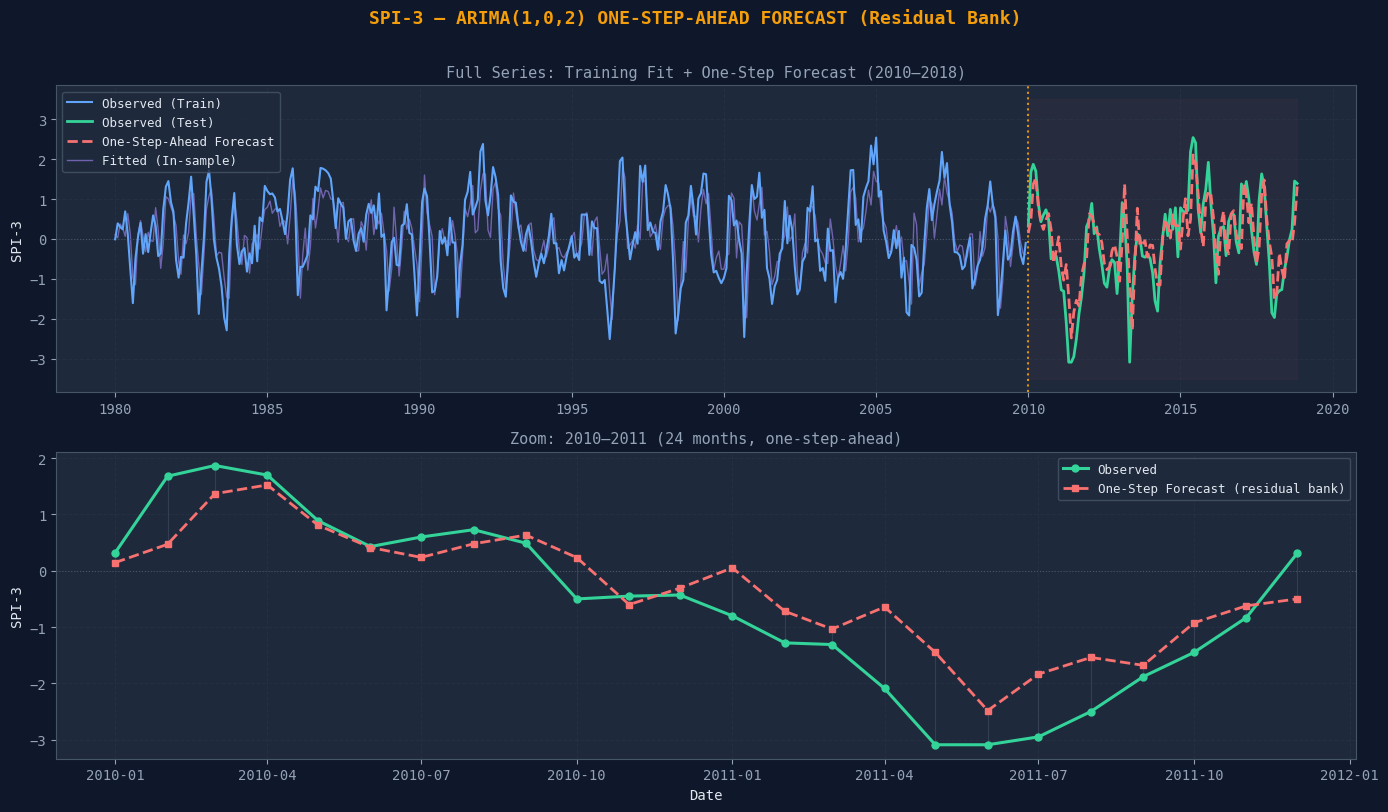

  ✓ Saved: 04_spi3_forecast_plot.png


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — OBSERVED vs PREDICTED PLOTS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 6: OBSERVED vs ONE-STEP-AHEAD FORECAST")
print("=" * 70)

fitted_train = final_model.fittedvalues
full_hat = pd.Series(df_fc['Y_hat'].values, index=df_fc['Date'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('SPI-3 — ARIMA(1,0,2) ONE-STEP-AHEAD FORECAST (Residual Bank)',
             fontsize=13, color=AMBER, fontweight='bold', y=1.01)

# Top panel
ax = axes[0]
ax.plot(train.index, train.values, color=BLUE, lw=1.5, label='Observed (Train)', zorder=3)
ax.plot(test.index,  test.values,  color=GREEN, lw=2.0, label='Observed (Test)', zorder=3)
ax.plot(full_hat.index, full_hat.values, color=ROSE, lw=2.0, ls='--',
        label='One-Step-Ahead Forecast', zorder=4)
ax.plot(fitted_train.index, fitted_train.values, color=PURPLE, lw=1.0,
        alpha=0.6, label='Fitted (In-sample)', zorder=2)
ax.axvline(pd.to_datetime('2010-01-01'), color=AMBER, lw=1.5, ls=':', alpha=0.9)
ax.axhline(0, color='#475569', lw=0.8, ls=':')
ax.fill_betweenx([-3.5, 3.5], pd.to_datetime('2010-01-01'),
                 test.index.max(), alpha=0.04, color=ROSE)
ax.set_ylabel('SPI-3')
ax.set_title('Full Series: Training Fit + One-Step Forecast (2010–2018)', color=SLATE)
ax.legend(fontsize=9, loc='upper left'); ax.grid(True, alpha=0.3)

# Bottom: zoom 2010–2011
ax2 = axes[1]
zoom_start = pd.to_datetime('2010-01-01')
zoom_end   = pd.to_datetime('2011-12-01')
obs_zoom = pd.concat([train, test]).sort_index().loc[zoom_start:zoom_end]
hat_zoom = full_hat.loc[zoom_start:zoom_end]

ax2.plot(obs_zoom.index, obs_zoom.values, color=GREEN, lw=2.2, marker='o', ms=5,
         label='Observed', zorder=3)
ax2.plot(hat_zoom.index, hat_zoom.values, color=ROSE, lw=2.0, marker='s', ms=4,
         ls='--', label='One-Step Forecast (residual bank)', zorder=4)
for dt in obs_zoom.index:
    if dt in hat_zoom.index:
        ax2.vlines(dt, min(obs_zoom.loc[dt], hat_zoom.loc[dt]),
                   max(obs_zoom.loc[dt], hat_zoom.loc[dt]),
                   color='#475569', lw=0.8, alpha=0.5)
ax2.axhline(0, color='#475569', lw=0.8, ls=':')
ax2.set_xlabel('Date'); ax2.set_ylabel('SPI-3')
ax2.set_title('Zoom: 2010–2011 (24 months, one-step-ahead)', color=SLATE)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_spi3_forecast_plot.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show(); print("  ✓ Saved: 04_spi3_forecast_plot.png")




  SECTION 7: FORECAST EVALUATION — SCATTER & ERROR BARS


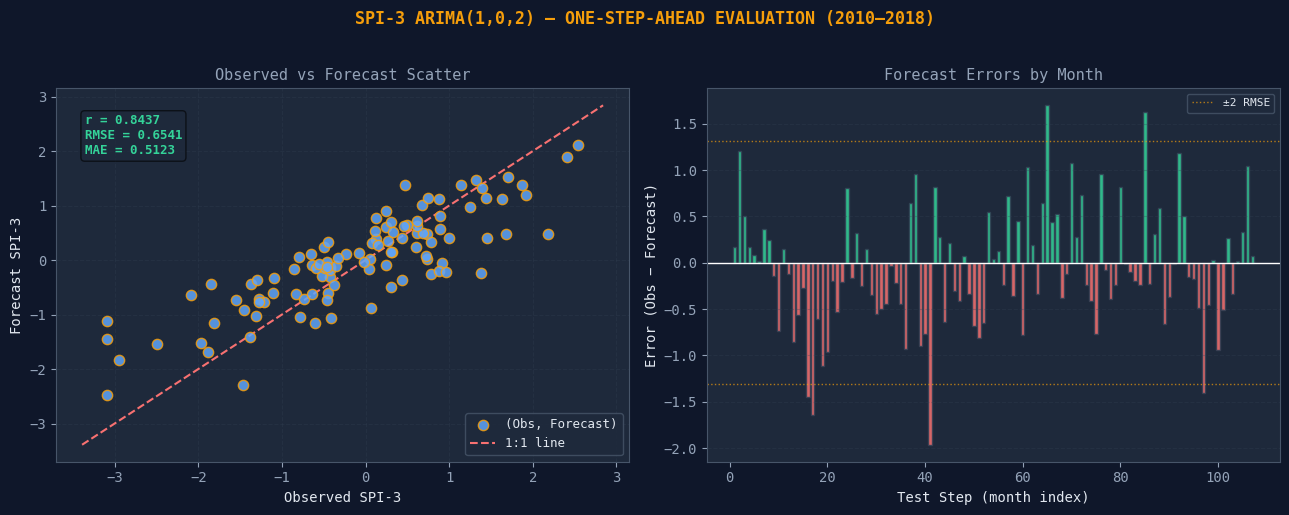

  ✓ Saved: 05_spi3_forecast_evaluation.png


In [25]:

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7 — SCATTER + ERROR BARS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 7: FORECAST EVALUATION — SCATTER & ERROR BARS")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('SPI-3 ARIMA(1,0,2) — ONE-STEP-AHEAD EVALUATION (2010–2018)',
             fontsize=12, color=AMBER, fontweight='bold', y=1.02)

# Scatter
ax = axes[0]
obs  = df_fc['Y_obs'].values
pred = df_fc['Y_hat'].values
ax.scatter(obs, pred, color=BLUE, edgecolors=AMBER, s=55, alpha=0.85, zorder=3,
           label='(Obs, Forecast)')
lims = [min(obs.min(), pred.min()) - 0.3, max(obs.max(), pred.max()) + 0.3]
ax.plot(lims, lims, color=ROSE, lw=1.5, ls='--', label='1:1 line')
ax.set_xlabel('Observed SPI-3'); ax.set_ylabel('Forecast SPI-3')
ax.set_title('Observed vs Forecast Scatter', color=SLATE)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.text(0.05, 0.93, f'r = {r:.4f}\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}',
        transform=ax.transAxes, color=GREEN, fontsize=9,
        fontweight='bold', va='top',
        bbox=dict(boxstyle='round', facecolor='#1e293b', alpha=0.6))

# Error bars
ax2 = axes[1]
errors = df_fc['Error'].values
colors_err = [GREEN if e >= 0 else ROSE for e in errors]
ax2.bar(range(1, len(errors)+1), errors, color=colors_err,
        edgecolor='#334155', width=0.7, alpha=0.85)
ax2.axhline(0, color='white', lw=1)
ax2.axhline(+2*rmse, color=AMBER, lw=1, ls=':', alpha=0.7, label='±2 RMSE')
ax2.axhline(-2*rmse, color=AMBER, lw=1, ls=':', alpha=0.7)
ax2.set_xlabel('Test Step (month index)')
ax2.set_ylabel('Error (Obs − Forecast)')
ax2.set_title('Forecast Errors by Month', color=SLATE)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('05_spi3_forecast_evaluation.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show(); print("  ✓ Saved: 05_spi3_forecast_evaluation.png")




  SECTION 8: RESIDUAL DIAGNOSTICS (Training Residuals)


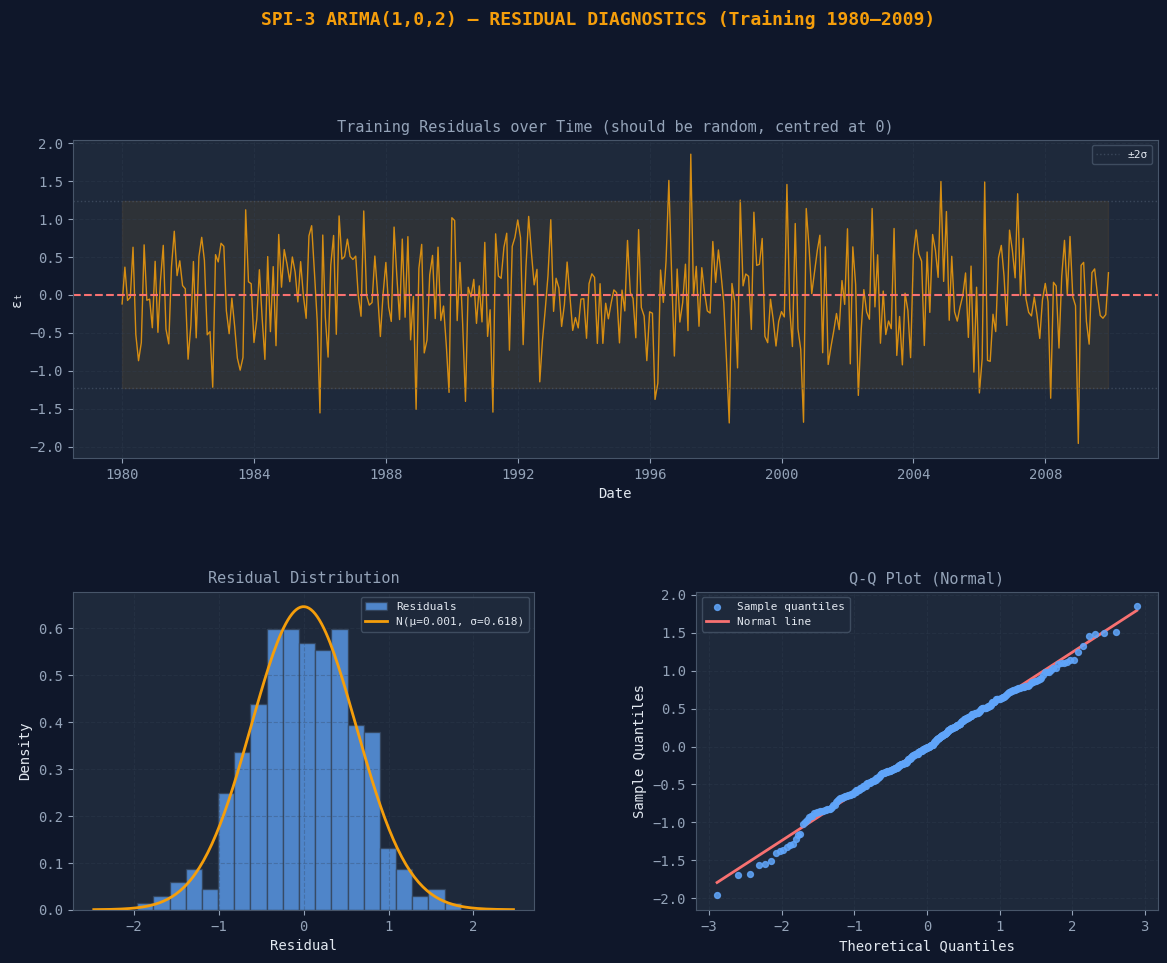

  ✓ Saved: 06_spi3_diagnostics.png


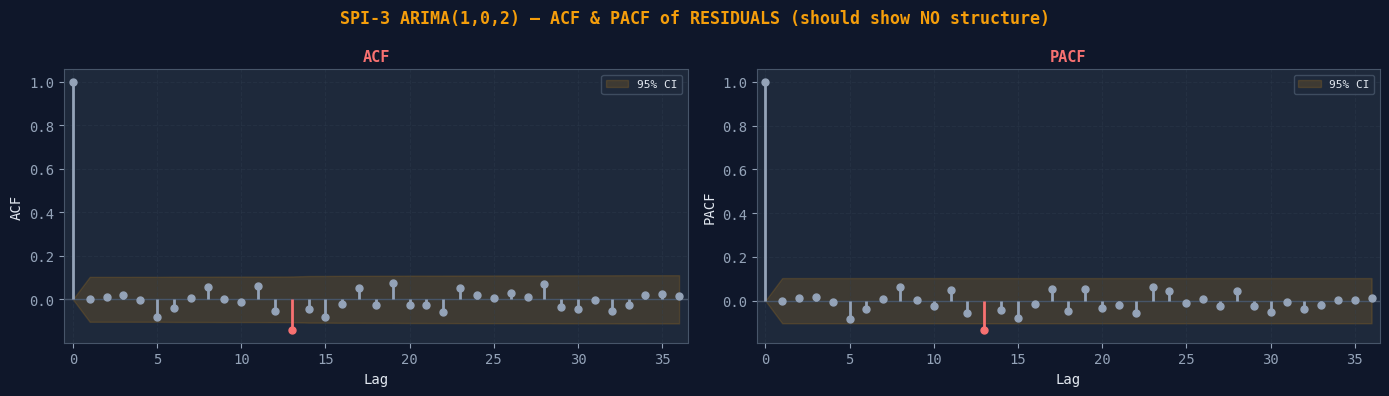

  ✓ Saved: 07_spi3_resid_acf_pacf.png


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8 — RESIDUAL DIAGNOSTICS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 8: RESIDUAL DIAGNOSTICS (Training Residuals)")
print("=" * 70)

residuals = final_model.resid.dropna()

fig = plt.figure(figsize=(14, 10))
fig.suptitle('SPI-3 ARIMA(1,0,2) — RESIDUAL DIAGNOSTICS (Training 1980–2009)',
             fontsize=13, color=AMBER, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.35)

# 1) Residuals vs time
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(residuals.index, residuals.values, color=AMBER, lw=1.0, alpha=0.85)
ax1.axhline(0, color=ROSE, lw=1.5, ls='--')
sig = np.std(residuals.values)
ax1.axhline(+2*sig, color='#475569', lw=1, ls=':', alpha=0.7, label='±2σ')
ax1.axhline(-2*sig, color='#475569', lw=1, ls=':', alpha=0.7)
ax1.fill_between(residuals.index, -2*sig, 2*sig, alpha=0.08, color=AMBER)
ax1.set_xlabel('Date'); ax1.set_ylabel('εₜ')
ax1.set_title('Training Residuals over Time (should be random, centred at 0)', color=SLATE)
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# 2) Histogram + normal
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(residuals.values, bins=20, color=BLUE, edgecolor='#334155',
         alpha=0.75, density=True, label='Residuals')
mu_r, std_r = residuals.mean(), residuals.std()
xr = np.linspace(mu_r - 4*std_r, mu_r + 4*std_r, 200)
ax2.plot(xr, stats.norm.pdf(xr, mu_r, std_r), color=AMBER, lw=2,
         label=f'N(μ={mu_r:.3f}, σ={std_r:.3f})')
ax2.set_xlabel('Residual'); ax2.set_ylabel('Density')
ax2.set_title('Residual Distribution', color=SLATE)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# 3) Q-Q plot
ax3 = fig.add_subplot(gs[1, 1])
(osm, osr), (slope, intercept, _) = stats.probplot(residuals.values, dist='norm')
ax3.scatter(osm, osr, color=BLUE, s=18, alpha=0.85, zorder=3, label='Sample quantiles')
ax3.plot(osm, slope*np.array(osm)+intercept, color=ROSE, lw=2, label='Normal line')
ax3.set_xlabel('Theoretical Quantiles'); ax3.set_ylabel('Sample Quantiles')
ax3.set_title('Q-Q Plot (Normal)', color=SLATE)
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

plt.savefig('06_spi3_diagnostics.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show(); print("  ✓ Saved: 06_spi3_diagnostics.png")

# ── ACF/PACF of residuals ─────────────────────────────────────────────────────
styled_acf_pacf(residuals,
                'SPI-3 ARIMA(1,0,2) — ACF & PACF of RESIDUALS (should show NO structure)',
                '07_spi3_resid_acf_pacf.png', nlags=36, color=ROSE)




  SECTION 9: MULTI-STEP LEAD COMPARISON (Lead 1–6)

    Lead      RMSE       MAE    sMAPE%      Bias
  ──────────────────────────────────────────────
  Lead-1   0.65414   0.51229    85.783  -0.07419
  Lead-2   0.97273   0.75914   124.029  -0.13863
  Lead-3   1.18102   0.92613   162.232  -0.20318
  Lead-4   1.19884   0.93472   158.474  -0.21337
  Lead-5   1.20108   0.93687   158.716  -0.21492
  Lead-6   1.20142   0.93711   158.730  -0.21514


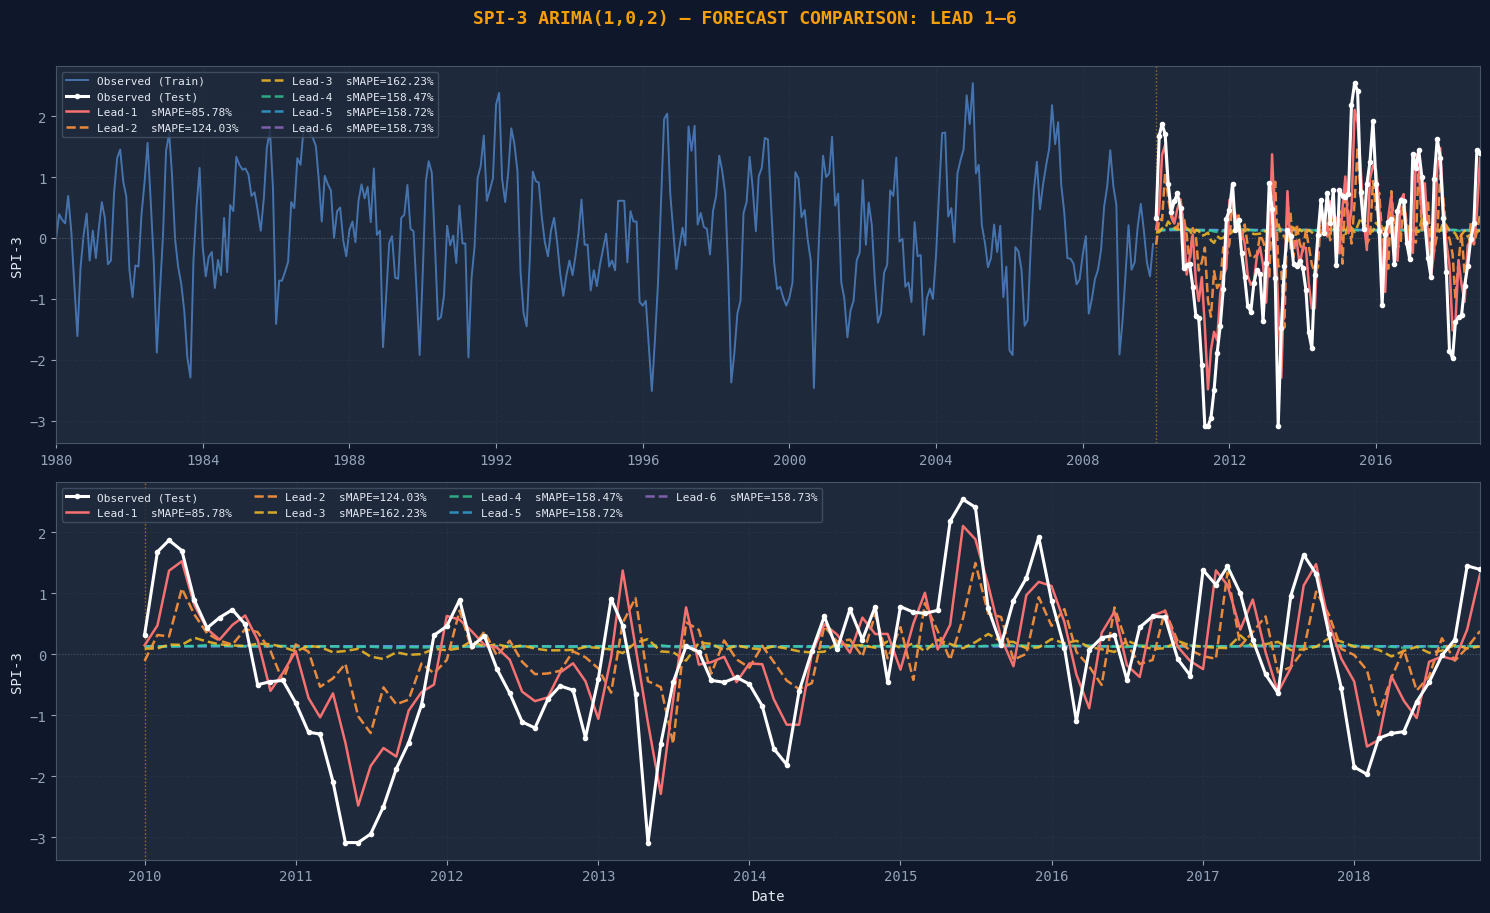

  ✓ Saved: 08_spi3_multi_lead.png


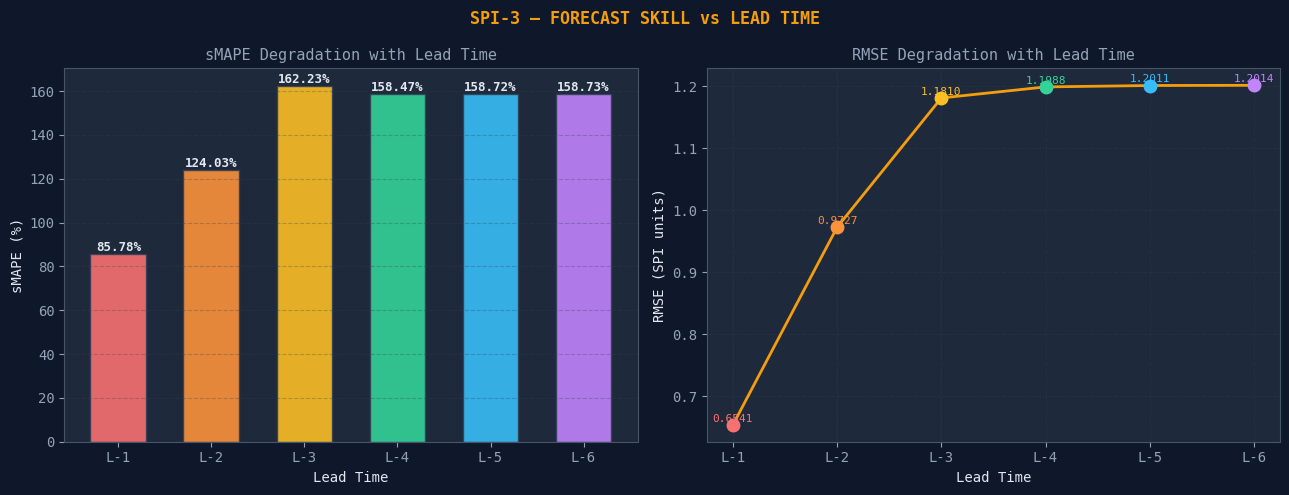

  ✓ Saved: 09_spi3_lead_skill.png


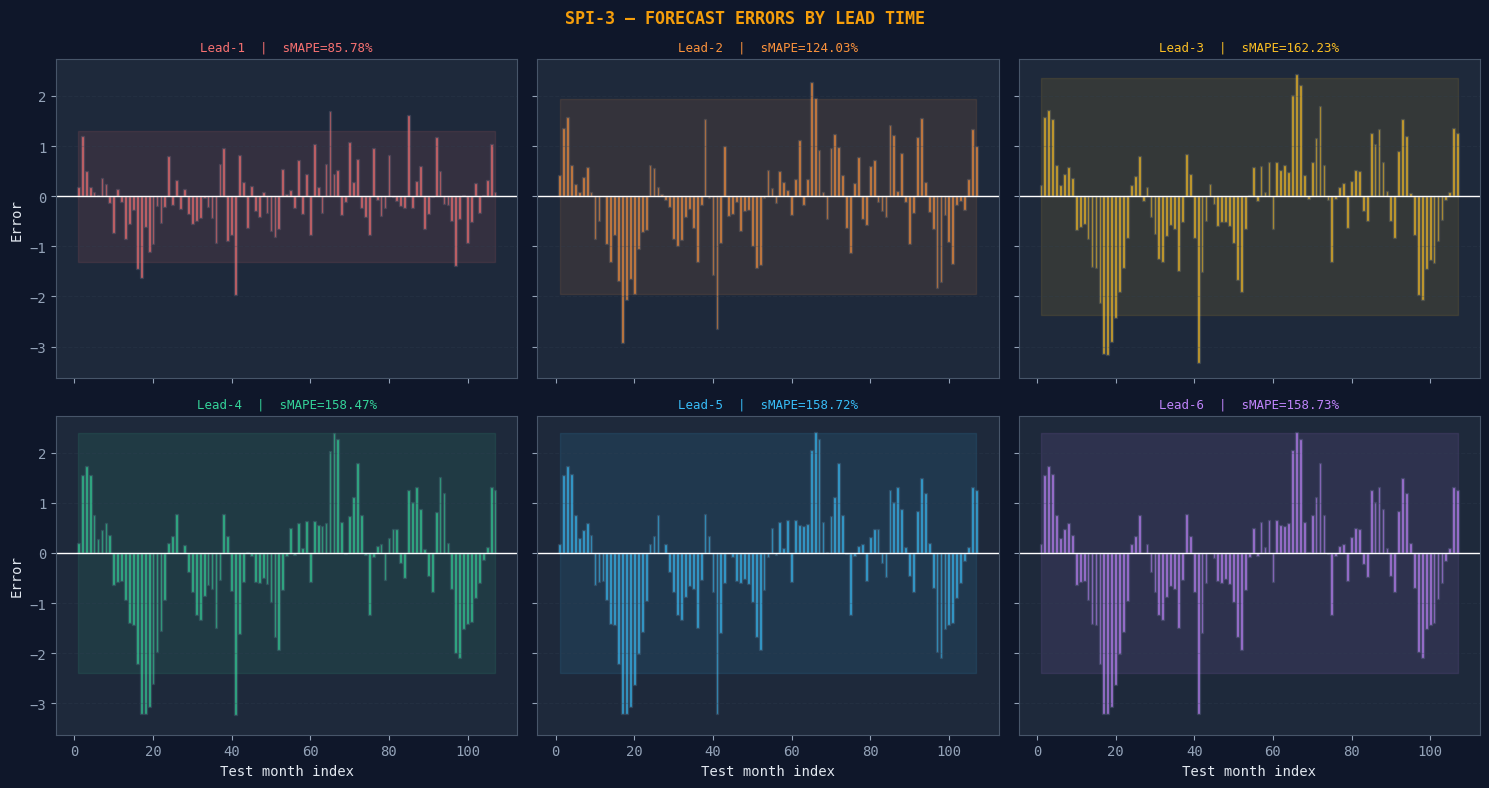

  ✓ Saved: 10_spi3_lead_error_panels.png

╔══════════════════════════════════════════════════════════════════════╗
║              SPI-3 ARIMA ANALYSIS — COMPLETE                        ║
╠══════════════════════════════════════════════════════════════════════╣
║  Saved files:                                                        ║
║    01_spi3_train_test_split.png   — Train/test series               ║
║    02_spi3_acf_pacf_train.png     — ACF/PACF training data          ║
║    03_spi3_model_comparison.png   — AIC/BIC candidate models        ║
║    04_spi3_forecast_plot.png      — Observed vs forecast            ║
║    05_spi3_forecast_evaluation.png— Scatter + error bars            ║
║    06_spi3_diagnostics.png        — Residual diagnostics            ║
║    07_spi3_resid_acf_pacf.png     — ACF/PACF of residuals           ║
║    08_spi3_multi_lead.png         — Lead 1–6 forecast comparison    ║
║    09_spi3_lead_skill.png         — sMAPE/RMSE degradation          ║
║    10_spi3_lead_e

In [26]:




# ══════════════════════════════════════════════════════════════════════════════
# SECTION 9 — MULTI-STEP LEAD COMPARISON (Lead 1–6)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 9: MULTI-STEP LEAD COMPARISON (Lead 1–6)")
print("=" * 70)

MAX_LEAD = 6

def forecast_lead_h_arma102(y_all, resid_bank_full, t_idx, h,
                              c_, phi1, th1, th2):
    """
    Lead-h forecast for ARIMA(1,0,2) at position t_idx.
    Uses recursive forecasting h steps forward from origin t_idx - h.
    MA error terms are set to 0 if they fall beyond the residual bank.
    """
    buf_y   = list(y_all[:t_idx - h + 1])      # actual values up to origin
    buf_eps = list(resid_bank_full[:t_idx - h + 1])  # residuals up to origin

    for step_h in range(h):
        n = len(buf_y)
        y_prev   = buf_y[-1]
        # eps at t-1: in buf_eps if step_h < 1, else 0 (future)
        eps_tm1  = buf_eps[-1]   if len(buf_eps) > n - 1 else 0.0
        eps_tm2  = buf_eps[-2]   if len(buf_eps) > n - 2 else 0.0

        y_hat_h = c_ + phi1 * y_prev + th1 * eps_tm1 + th2 * eps_tm2
        buf_y.append(y_hat_h)
        buf_eps.append(0.0)          # future eps → 0 for subsequent steps

    return buf_y[-1]


# Build full residual bank (training + test one-step residuals)
full_resid_bank = list(final_model.resid.values)   # training
for row in forecasts:
    full_resid_bank.append(row['Error'])            # test residuals appended

lead_results = {}
print(f"\n  {'Lead':>6}  {'RMSE':>8}  {'MAE':>8}  {'sMAPE%':>8}  {'Bias':>8}")
print("  " + "─" * 46)

for h in range(1, MAX_LEAD + 1):
    preds_h, errors_h = [], []
    for step in range(n_test):
        t_idx = n_train + step
        y_hat_h = forecast_lead_h_arma102(
            y_all, full_resid_bank, t_idx, h, c_, phi1, th1, th2)
        y_obs_h = y_all[t_idx]
        preds_h.append(y_hat_h)
        errors_h.append(y_obs_h - y_hat_h)

    arr_e = np.array(errors_h)
    arr_o = test_vals
    arr_p = np.array(preds_h)
    rmse_h  = np.sqrt(np.mean(arr_e**2))
    mae_h   = np.mean(np.abs(arr_e))
    smape_h = np.mean(200*np.abs(arr_e)/(np.abs(arr_o)+np.abs(arr_p)+1e-8))
    bias_h  = np.mean(arr_e)
    lead_results[h] = dict(preds=preds_h, errors=errors_h,
                            rmse=rmse_h, mae=mae_h, smape=smape_h, bias=bias_h)
    print(f"  Lead-{h}  {rmse_h:>8.5f}  {mae_h:>8.5f}  {smape_h:>8.3f}  {bias_h:>+8.5f}")


# ── Plot A: All leads on one plot ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 9))
fig.suptitle('SPI-3 ARIMA(1,0,2) — FORECAST COMPARISON: LEAD 1–6',
             fontsize=13, color=AMBER, fontweight='bold', y=1.01)

for idx, (ax, xlims) in enumerate([
    (axes[0], (train.index.min(), test.index.max())),
    (axes[1], (pd.to_datetime('2009-06-01'), test.index.max()))
]):
    if idx == 0:
        ax.plot(train.index, train.values, color=BLUE, lw=1.4, alpha=0.6,
                label='Observed (Train)')
    ax.plot(test.index, test.values, color='white', lw=2.2, marker='o', ms=3,
            label='Observed (Test)', zorder=5)
    for h in range(1, MAX_LEAD + 1):
        ax.plot(test.index, lead_results[h]['preds'],
                color=LEAD_COLORS[h-1], lw=1.8,
                ls='-' if h == 1 else '--',
                alpha=1.0 - (h-1)*0.08,
                label=f'{LEAD_LABELS[h-1]}  sMAPE={lead_results[h]["smape"]:.2f}%',
                zorder=4 - h*0.1)
    ax.axvline(pd.to_datetime('2010-01-01'), color=AMBER, lw=1, ls=':', alpha=0.6)
    ax.axhline(0, color='#475569', lw=0.8, ls=':')
    ax.set_xlim(*xlims)
    ax.set_ylabel('SPI-3')
    ax.legend(fontsize=8, loc='upper left', ncol=2 if idx==0 else 4)
    ax.grid(True, alpha=0.3)
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('08_spi3_multi_lead.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show(); print("  ✓ Saved: 08_spi3_multi_lead.png")


# ── Plot B: sMAPE & RMSE degradation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('SPI-3 — FORECAST SKILL vs LEAD TIME',
             fontsize=12, color=AMBER, fontweight='bold')
leads  = list(range(1, MAX_LEAD+1))
smapes = [lead_results[h]['smape'] for h in leads]
rmses  = [lead_results[h]['rmse']  for h in leads]

ax = axes[0]
bars = ax.bar(leads, smapes, color=LEAD_COLORS, edgecolor='#334155',
              width=0.6, alpha=0.9)
for bar, v in zip(bars, smapes):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.2f}%',
            ha='center', va='bottom', fontsize=9, color='#e2e8f0', fontweight='bold')
ax.set_xlabel('Lead Time'); ax.set_ylabel('sMAPE (%)')
ax.set_title('sMAPE Degradation with Lead Time', color=SLATE)
ax.set_xticks(leads); ax.set_xticklabels([f'L-{h}' for h in leads])
ax.grid(True, alpha=0.3, axis='y')

ax2 = axes[1]
ax2.plot(leads, rmses, color=AMBER, lw=2, marker='o', ms=7,
         markerfacecolor='#0f172a', markeredgewidth=2)
for h, r_v, c in zip(leads, rmses, LEAD_COLORS):
    ax2.plot(h, r_v, 'o', color=c, ms=9, zorder=4)
    ax2.text(h, r_v+0.002, f'{r_v:.4f}', ha='center', va='bottom', fontsize=8, color=c)
ax2.set_xlabel('Lead Time'); ax2.set_ylabel('RMSE (SPI units)')
ax2.set_title('RMSE Degradation with Lead Time', color=SLATE)
ax2.set_xticks(leads); ax2.set_xticklabels([f'L-{h}' for h in leads])
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('09_spi3_lead_skill.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show(); print("  ✓ Saved: 09_spi3_lead_skill.png")


# ── Plot C: Error panels per lead ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
fig.suptitle('SPI-3 — FORECAST ERRORS BY LEAD TIME',
             fontsize=12, color=AMBER, fontweight='bold')
for idx, h in enumerate(range(1, MAX_LEAD+1)):
    ax  = axes[idx//3][idx%3]
    errs = np.array(lead_results[h]['errors'])
    color = LEAD_COLORS[h-1]
    ax.bar(range(1, n_test+1), errs, color=color, edgecolor='#334155',
           width=0.7, alpha=0.8)
    ax.axhline(0, color='white', lw=1)
    ax.fill_between(range(1, n_test+1),
                    -2*lead_results[h]['rmse'], 2*lead_results[h]['rmse'],
                    alpha=0.1, color=color)
    ax.set_title(f'{LEAD_LABELS[h-1]}  |  sMAPE={lead_results[h]["smape"]:.2f}%',
                 color=color, fontsize=9)
    ax.grid(True, alpha=0.25, axis='y')
    if idx % 3 == 0: ax.set_ylabel('Error')
    if idx // 3 == 1: ax.set_xlabel('Test month index')
plt.tight_layout()
plt.savefig('10_spi3_lead_error_panels.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show(); print("  ✓ Saved: 10_spi3_lead_error_panels.png")

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║              SPI-3 ARIMA ANALYSIS — COMPLETE                        ║
╠══════════════════════════════════════════════════════════════════════╣
║  Saved files:                                                        ║
║    01_spi3_train_test_split.png   — Train/test series               ║
║    02_spi3_acf_pacf_train.png     — ACF/PACF training data          ║
║    03_spi3_model_comparison.png   — AIC/BIC candidate models        ║
║    04_spi3_forecast_plot.png      — Observed vs forecast            ║
║    05_spi3_forecast_evaluation.png— Scatter + error bars            ║
║    06_spi3_diagnostics.png        — Residual diagnostics            ║
║    07_spi3_resid_acf_pacf.png     — ACF/PACF of residuals           ║
║    08_spi3_multi_lead.png         — Lead 1–6 forecast comparison    ║
║    09_spi3_lead_skill.png         — sMAPE/RMSE degradation          ║
║    10_spi3_lead_error_panels.png  — Error panels per lead           ║
╠══════════════════════════════════════════════════════════════════════╣
║  ARIMA(1,0,2) Forecast Equation:                                     ║
║    Ŷₜ = c + φ₁·Yₜ₋₁ + θ₁·εₜ₋₁ + θ₂·εₜ₋₂                         ║
║  (εₜ₋₁, εₜ₋₂ from residual bank — NEVER re-fitted)                 ║
╚══════════════════════════════════════════════════════════════════════╝
""")

## Section 9 — Multi-Step Lead Comparison (Lead 1–6)

 ### What changes for Lead-h > 1?
 For Lead-h, we forecast h months ahead from each origin point.
 Specifically for ARIMA(1,0,2) at Lead-h > 2:

 | Lead | εₜ₋₁ | εₜ₋₂ |
 |------|------|------|
 | 1 | known (residual bank) | known (residual bank) |
 | 2 | ε at t-1 is **future** → set to 0 | known (residual bank) |
 | 3 | future → 0 | future → 0 |
 | 4+ | both future → 0 | both future → 0 |

 From Lead-3 onwards, all MA terms vanish and the model behaves purely as
 AR(1). This causes accuracy to plateau from Lead-3 onwards for ARIMA(1,0,2).